In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
# Load the dataset
data = pd.read_csv('loan_data.csv')
df = data.copy()
print(df.head())
# Prepare the data
print(len(df.columns.tolist()))
print(df.columns.tolist())

   person_age person_gender person_education  person_income  person_emp_exp  \
0        22.0        female           Master        71948.0               0   
1        21.0        female      High School        12282.0               0   
2        25.0        female      High School        12438.0               3   
3        23.0        female         Bachelor        79753.0               0   
4        24.0          male           Master        66135.0               1   

  person_home_ownership  loan_amnt loan_intent  loan_int_rate  \
0                  RENT    35000.0    PERSONAL          16.02   
1                   OWN     1000.0   EDUCATION          11.14   
2              MORTGAGE     5500.0     MEDICAL          12.87   
3                  RENT    35000.0     MEDICAL          15.23   
4                  RENT    35000.0     MEDICAL          14.27   

   loan_percent_income  cb_person_cred_hist_length  credit_score  \
0                 0.49                         3.0           561  

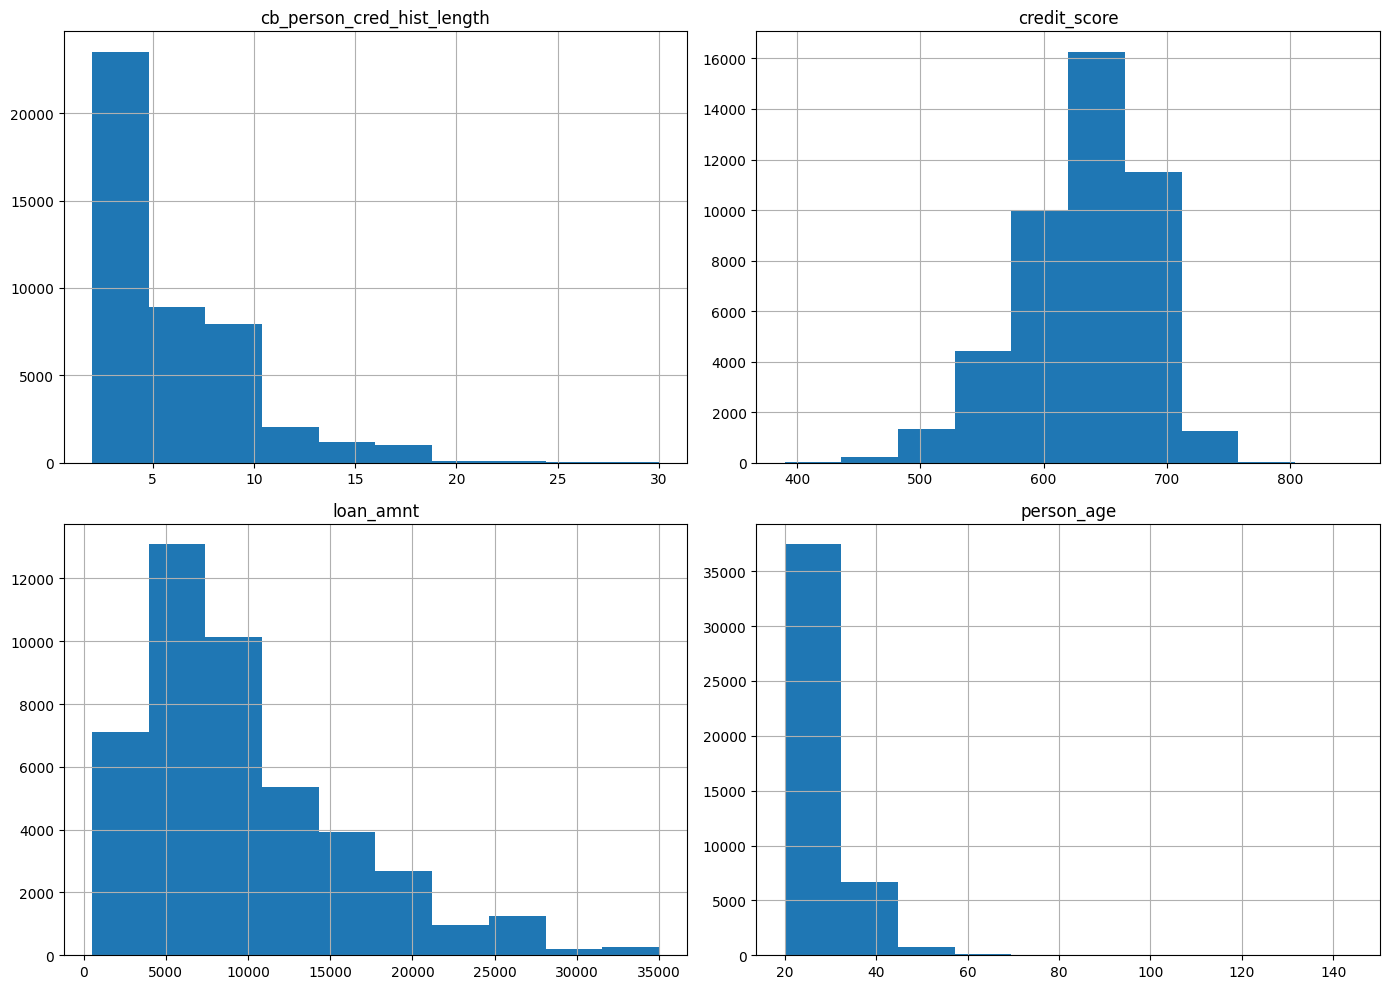

In [3]:
df[["cb_person_cred_hist_length","credit_score", "loan_amnt","person_age"]].hist(figsize=(14,10))
plt.tight_layout()
plt.show()

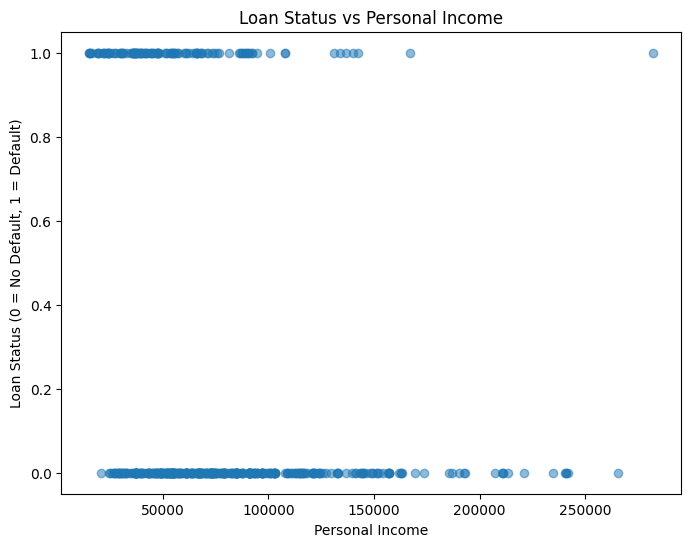

In [4]:
sample_df = df.sample(500, random_state=42)
plt.figure(figsize=(8,6))
plt.scatter(sample_df["person_income"], sample_df["loan_status"], alpha=0.5)
plt.xlabel("Personal Income")
plt.ylabel("Loan Status (0 = No Default, 1 = Default)")
plt.title("Loan Status vs Personal Income")
plt.show()

In [5]:
df_encoded = pd.get_dummies(df, drop_first=True)
bool_cols = df_encoded.select_dtypes(include=["bool"]).columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)
print(df_encoded.head())

   person_age  person_income  person_emp_exp  loan_amnt  loan_int_rate  \
0        22.0        71948.0               0    35000.0          16.02   
1        21.0        12282.0               0     1000.0          11.14   
2        25.0        12438.0               3     5500.0          12.87   
3        23.0        79753.0               0    35000.0          15.23   
4        24.0        66135.0               1    35000.0          14.27   

   loan_percent_income  cb_person_cred_hist_length  credit_score  loan_status  \
0                 0.49                         3.0           561            1   
1                 0.08                         2.0           504            0   
2                 0.44                         3.0           635            1   
3                 0.44                         2.0           675            1   
4                 0.53                         4.0           586            1   

   person_gender_male  ...  person_education_Master  \
0            

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

y = df_encoded["loan_status"].values.astype(float) 
X = df_encoded.drop(columns=["loan_status"]).values.astype(float) 
X = np.hstack((np.ones((X.shape[0], 1)), X))
m, n = X.shape


print("Unique y values:", np.unique(y))
print("y min/max:", y.min(), y.max())
print("y counts:", np.bincount(y.astype(int)) if set(np.unique(y)).issubset({0,1}) else "not 0/1")

X = np.c_[np.ones(m), X]
alpha = 0.01
epochs = 100
theta = np.zeros(X.shape[1], dtype=float)
loss_hist = []

def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1.0 / (1.0 + np.exp(-z))

for ep in range(epochs):
    for i in range(m):  
        xi = X[i]
        yi = y[i]

        prediction = sigmoid(xi @ theta)

        gradient = (prediction - yi) * xi
        theta = theta - alpha * gradient
    
    p = sigmoid(X @ theta)
    eps = 1e-12  # avoid log(0)
    loss = -np.mean(y * np.log(p + eps) + (1 - y) * np.log(1 - p + eps))
    loss_hist.append(loss)
print("Final theta:", theta)
print("Final loss:", loss_hist[-1])


Unique y values: [0. 1.]
y min/max: 0.0 1.0
y counts: [35000 10000]
Final theta: [ 1.04475000e+02  1.04475000e+02  4.17808001e+03  1.74621029e+03
  1.62705000e+03  1.66046440e+04  1.16485592e+04 -2.60805499e+01
  1.42680500e+03  3.80492253e+04  8.00000000e-02  3.51600000e+01
  4.74000000e+00  5.81200000e+01  3.61150005e+01  1.01400000e+01
 -4.59930000e+02  7.54885000e+02 -2.47600000e+02  2.00370000e+02
  2.68810000e+02 -5.17450000e+01 -4.02610000e+02 -2.39629000e+03]
Final loss: 21.490794201277534


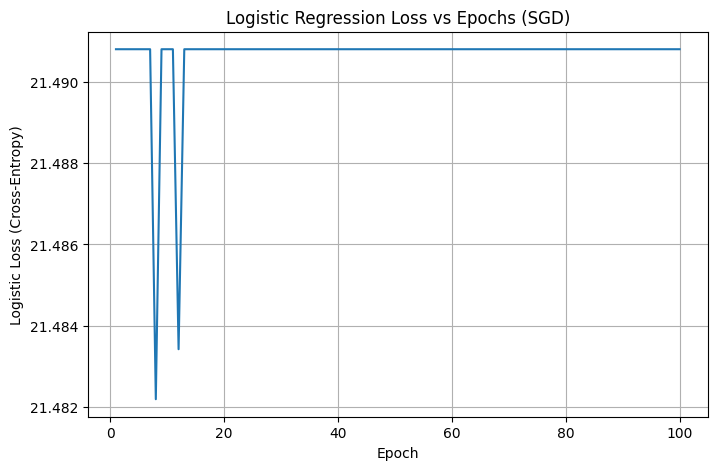

In [7]:
plt.figure(figsize=(8,5))
plt.plot(range(1, epochs+1), loss_hist)
plt.xlabel("Epoch")
plt.ylabel("Logistic Loss (Cross-Entropy)")
plt.title("Logistic Regression Loss vs Epochs (SGD)")
plt.grid(True)
plt.show()


In [17]:
y = df_encoded["loan_status"].values.astype(float) 
X = df_encoded.drop(columns=["loan_status"]).values.astype(float) 
mu=X.mean(axis=0)
sigma=X.std(axis=0)
X=(X-mu)/sigma
X = np.hstack((np.ones((X.shape[0], 1)), X))
m, n = X.shape


alpha = 0.01
epochs = 100
theta = np.zeros(X.shape[1], dtype=float)
loss_hist = []

def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1.0 / (1.0 + np.exp(-z))

for ep in range(epochs):
    for i in range(m):  
        xi = X[i]
        yi = y[i]

        prediction = sigmoid(xi @ theta)

        gradient = (prediction - yi) * xi
        theta = theta - alpha * gradient
    
    p = sigmoid(X @ theta)
    eps = 1e-12  # avoid log(0)
    loss = -np.mean(y * np.log(p + eps) + (1 - y) * np.log(1 - p + eps))
    loss_hist.append(loss)
print("Final theta:", theta)
print("Final loss:", loss_hist[-1])


Final theta: [-4.45159293  0.35963904 -0.02049542 -0.35994677 -0.65885614  1.43336017
  1.36406869  0.25854067 -0.17165685 -0.02193451  0.01477578  0.15951043
 -0.0987501   0.02932018 -0.01868665 -0.62640764  0.6143438  -0.44961589
 -0.13609105 -0.03975568 -0.33356984 -0.7382188  -7.06609661]
Final loss: 0.65665884707121


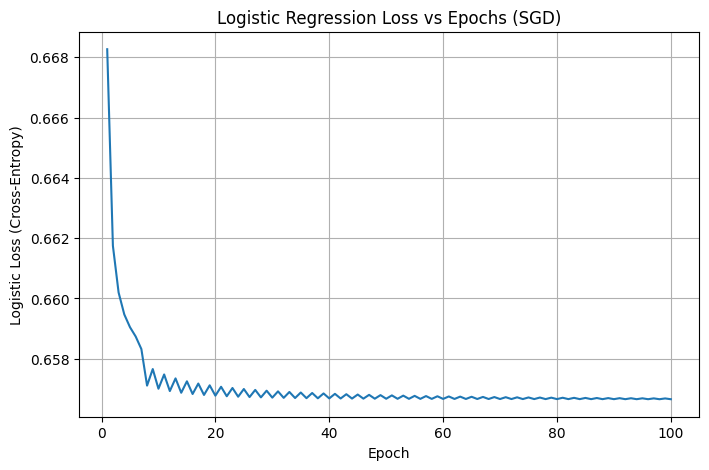

In [18]:
plt.figure(figsize=(8,5))
plt.plot(range(1, epochs+1), loss_hist)
plt.xlabel("Epoch")
plt.ylabel("Logistic Loss (Cross-Entropy)")
plt.title("Logistic Regression Loss vs Epochs (SGD)")
plt.grid(True)
plt.show()

In [19]:
# accuracy
probs = sigmoid(X @ theta)               # predicted probabilities
y_pred = (probs >= 0.5).astype(int)      # predicted labels 0/1

# confusion pieces
TP = np.sum((y == 1) & (y_pred == 1))
TN = np.sum((y == 0) & (y_pred == 0))
FP = np.sum((y == 0) & (y_pred == 1))
FN = np.sum((y == 1) & (y_pred == 0))

accuracy = (TP + TN) / (TP + TN + FP + FN) * 100

print(f"TP={TP}, TN={TN}, FP={FP}, FN={FN}")
print(f"Accuracy on entire dataset: {accuracy:.2f}%")

TP=9890, TN=24910, FP=10090, FN=110
Accuracy on entire dataset: 77.33%


In [20]:
# train without person_gender, person_education and person_age
X = df_encoded.drop(columns=["loan_status", "person_gender_male", "person_education_Master", "person_age"]).values.astype(float) 
mu=X.mean(axis=0)
sigma=X.std(axis=0)
X=(X-mu)/sigma
X = np.hstack((np.ones((X.shape[0], 1)), X))
m, n = X.shape
alpha = 0.01
epochs = 100
theta = np.zeros(X.shape[1], dtype=float)
loss_hist = []

def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1.0 / (1.0 + np.exp(-z))

for ep in range(epochs):
    for i in range(m):  
        xi = X[i]
        yi = y[i]

        prediction = sigmoid(xi @ theta)

        gradient = (prediction - yi) * xi
        theta = theta - alpha * gradient
    
    p = sigmoid(X @ theta)
    eps = 1e-12  # avoid log(0)
    loss = -np.mean(y * np.log(p + eps) + (1 - y) * np.log(1 - p + eps))
    loss_hist.append(loss)
print("Final theta:", theta)
print("Final loss:", loss_hist[-1])

Final theta: [-4.44074756e+00 -3.76378768e-02 -1.23856282e-01 -6.37555366e-01
  1.42606444e+00  1.33776799e+00  3.24543353e-01 -1.69070193e-01
 -5.90111468e-03  1.56220173e-01 -1.15556035e-01 -1.79044896e-02
 -6.17808970e-01  6.09653919e-01 -4.50964286e-01 -1.38169927e-01
 -3.77377146e-02 -3.31424501e-01 -7.34229494e-01 -7.06570568e+00]
Final loss: 0.657783158236499


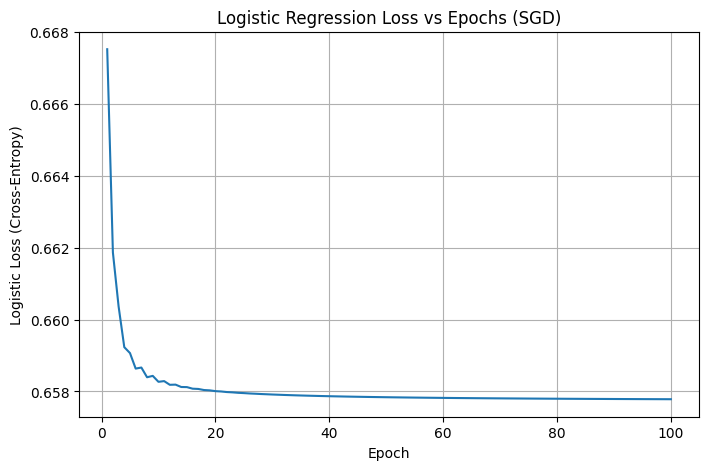

In [21]:
plt.figure(figsize=(8,5))
plt.plot(range(1, epochs+1), loss_hist)
plt.xlabel("Epoch")
plt.ylabel("Logistic Loss (Cross-Entropy)")
plt.title("Logistic Regression Loss vs Epochs (SGD)")
plt.grid(True)
plt.show()

In [22]:
# accuracy
probs = sigmoid(X @ theta)               # predicted probabilities
y_pred = (probs >= 0.5).astype(int)      # predicted labels 0/1

# confusion pieces
TP = np.sum((y == 1) & (y_pred == 1))
TN = np.sum((y == 0) & (y_pred == 0))
FP = np.sum((y == 0) & (y_pred == 1))
FN = np.sum((y == 1) & (y_pred == 0))

accuracy = (TP + TN) / (TP + TN + FP + FN) * 100

print(f"TP={TP}, TN={TN}, FP={FP}, FN={FN}")
print(f"Accuracy on entire dataset: {accuracy:.2f}%")

TP=9888, TN=24866, FP=10134, FN=112
Accuracy on entire dataset: 77.23%
